## Feature Engineering

This notebook derives behavioral and temporal features that
capture payment trends, volatility, and stress signals.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"
df = pd.read_csv(path)

df.shape

(30000, 31)

In [ ]:
y = df['default']

In [ ]:
baseline_features = [
    'LIMIT_BAL', 'AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'
]

In [ ]:
early_warning_features = [
    'pay_delay_volatility',
    'pay_trend',
    'avg_utilization'
]

In [ ]:
X_baseline = df[baseline_features]
X_early = df[baseline_features + early_warning_features]

In [ ]:
df[['PAY_6','PAY_5','PAY_4','PAY_3','PAY_2','PAY_0','default']].head()

,PAY_6,PAY_5,PAY_4,PAY_3,PAY_2,PAY_0,default
0,-2,-2,-1,-1,2,2,1
1,2,0,0,0,2,-1,1
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,-1,0,-1,0


Raw monthly values capture snapshots but fail to describe trajectories. Early financial stress manifests as worsening trends, rising volatility, and increasing recency-weighted risk. This notebook converts longitudinal behavior into interpretable temporal signals.

In [ ]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.3, stratify=y, random_state=42
)

Xe_train, Xe_test, _, _ = train_test_split(
    X_early, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(Xb_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
early_model = LogisticRegression(max_iter=1000)
early_model.fit(Xe_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(y_test, baseline_model.predict_proba(Xb_test)[:,1])
early_auc = roc_auc_score(y_test, early_model.predict_proba(Xe_test)[:,1])

baseline_auc, early_auc

(np.float64(0.7084062974496663), np.float64(0.720170357133567))

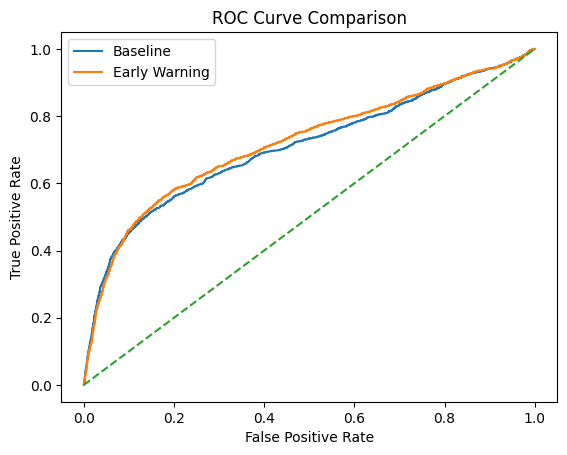

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_b, tpr_b, _ = roc_curve(y_test, baseline_model.predict_proba(Xb_test)[:,1])
fpr_e, tpr_e, _ = roc_curve(y_test, early_model.predict_proba(Xe_test)[:,1])

plt.figure()
plt.plot(fpr_b, tpr_b, label='Baseline')
plt.plot(fpr_e, tpr_e, label='Early Warning')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_early.columns,
    'coefficient': early_model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

feature_importance.head(10)

,feature,coefficient
8,pay_delay_volatility,0.481959
10,avg_utilization,-0.425614
2,PAY_0,0.354004
7,PAY_6,0.220323
9,pay_trend,0.133681
3,PAY_2,0.128410
4,PAY_3,0.051602
6,PAY_5,0.049150
5,PAY_4,-0.011204
1,AGE,0.006621


The engineered features are saved for modeling in the next stage.


In [ ]:
save_path = "/content/drive/MyDrive/Credit_Risk_Project/data/model_ready.csv"
df.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Credit_Risk_Project/data/model_ready.csv
